# Notebook 2:  Clustering con Modelo de Mezclas de Normales (GMM)
En este notebook vamos a implementar el algoritmo de clustering de Mezcla de Normales en R. El objetivo es entender como funciona este algoritmo y aprender a utilizarlo con un ejemplo simple. Se incluye además la estrategia para definir el número de grupos k. Al final se propone un ejercicio considerando el uso de un función que permita medir la calidad del agrupamiento cuando se conocen los grupos de cada observación.

In [111]:
#install.packages("mclust")
#install.packages("cluster")
#install.packages("factoextra") # demora un poco esto en instalar
#install.packages("clustMD")
library(mclust)
library(cluster)
library(ggplot2)
library(factoextra)
library(fastDummies)
library(clustMD)
#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos <-read.table("..//data//semillas1.txt",dec=".")
summary(datos)

       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EEV (ellipsoidal, equal volume and shape) model with 4 components: 

 log-likelihood   n df       BIC       ICL
       177.3167 210 93 -142.6475 -157.7975

Clustering table:
 1  2  3  4 
67 75 23 45 

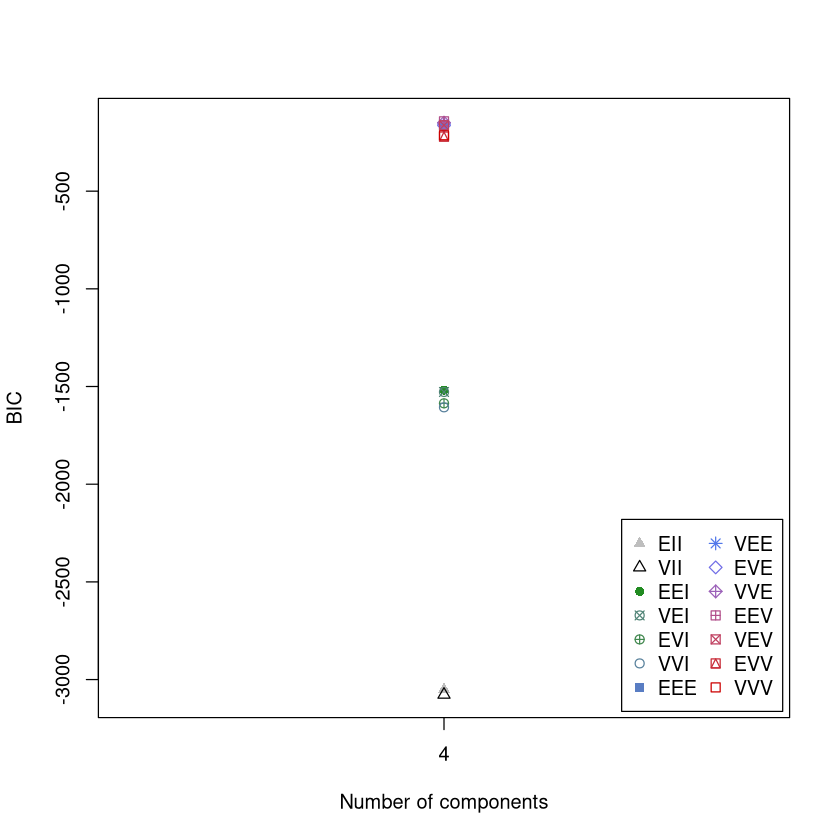

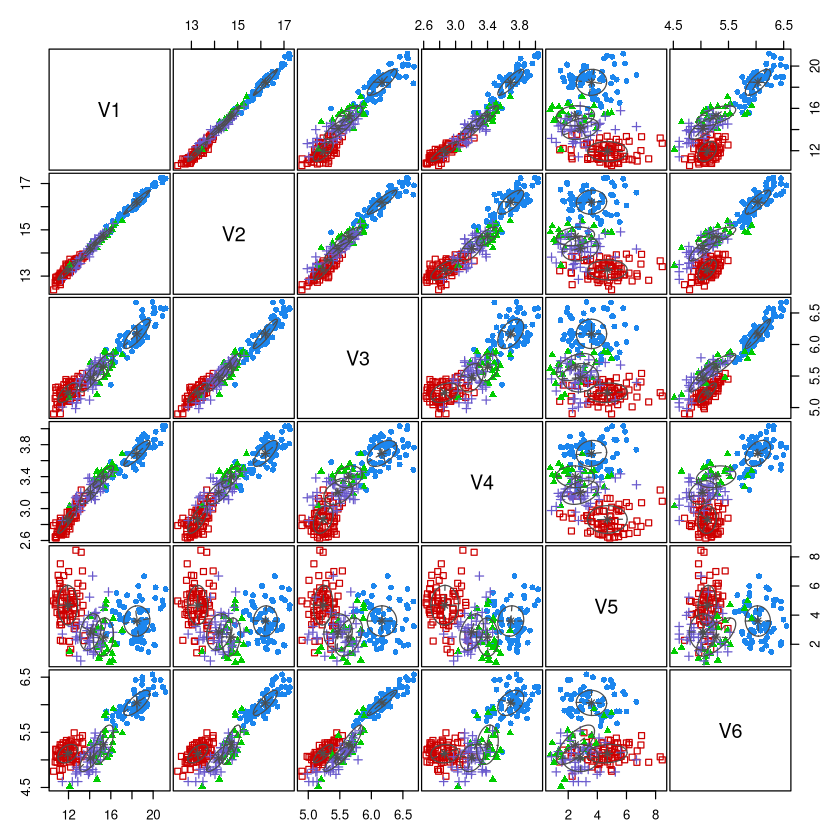

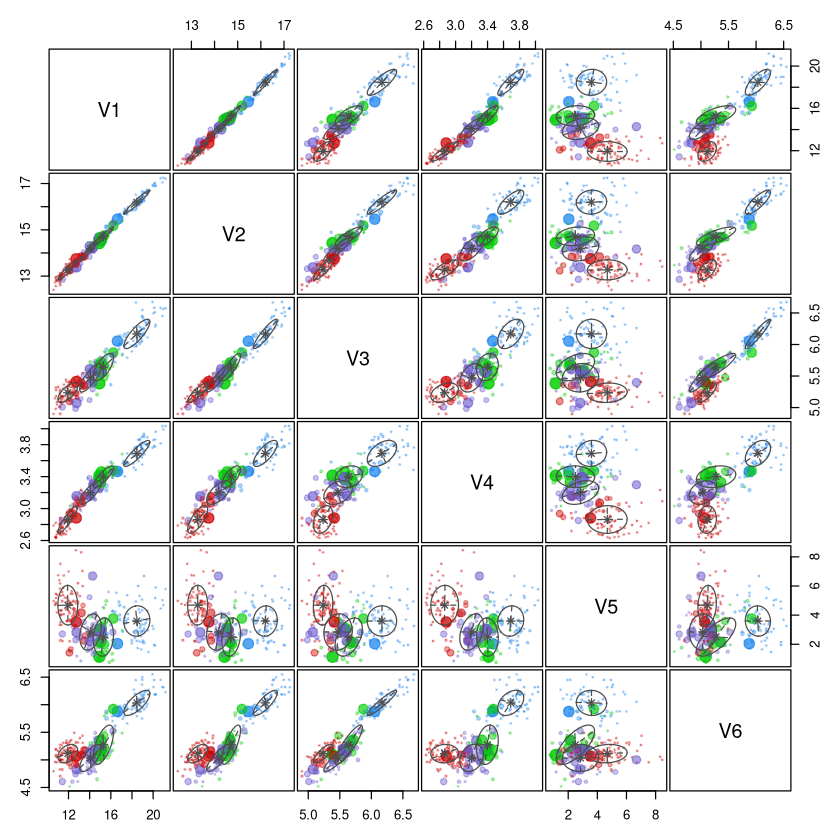

'Mclust' model object: (EEV,4) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   

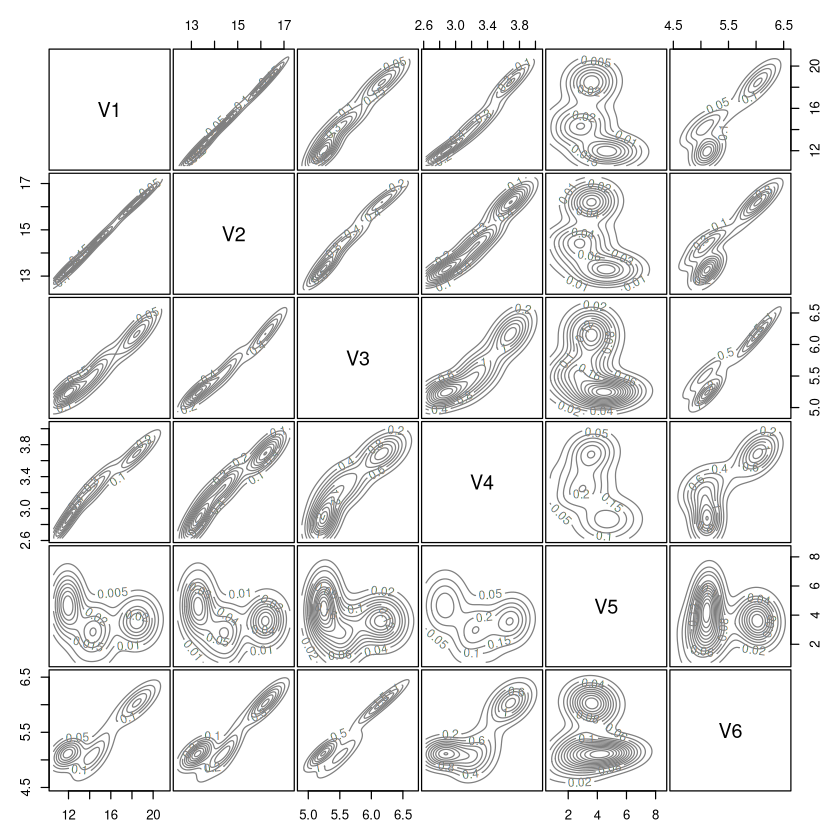

In [112]:
clus <-Mclust(datos, G=4)
summary(clus)
plot(clus)
clus




In [113]:
cl <- clus$classification
centers <- t(clus$parameters$mean)
centers




V1,V2,V3,V4,V5,V6
18.46213,16.19470,6.167813,3.690301,3.596481,6.033091
11.93175,13.27016,5.234781,2.863010,4.682985,5.113286
15.29414,14.71759,5.641832,3.398164,2.495003,5.274619
14.07522,14.18237,5.472207,3.200684,2.842341,5.035122


,V1,V2,V3,V4,V5,V6
Min.,15.57000,14.89000,5.363000,3.231000,1.472000,5.144000
1st Qu.,17.59000,15.85500,6.011500,3.564500,2.781000,5.879000
Median,18.75000,16.23000,6.153000,3.719000,3.477000,6.009000
Mean,18.46985,16.19896,6.170239,3.690612,3.587657,6.034567
3rd Qu.,19.14500,16.58000,6.328000,3.808000,4.362500,6.192500
Max.,21.18000,17.25000,6.675000,4.033000,6.682000,6.550000


,V1,V2,V3,V4,V5,V6
Min.,10.59000,12.4100,4.89900,2.630000,1.415000,4.703000
1st Qu.,11.26500,13.0050,5.13850,2.750000,3.952000,5.002000
Median,11.87000,13.2700,5.23600,2.840000,4.756000,5.091000
Mean,11.93013,13.2716,5.23656,2.861387,4.671627,5.115467
3rd Qu.,12.47500,13.5250,5.34900,2.967500,5.430000,5.220500
Max.,13.54000,13.9500,5.54100,3.232000,8.456000,5.491000


,V1,V2,V3,V4,V5,V6
Min.,12.11000,13.47000,5.159000,3.032000,0.765000,4.51900
1st Qu.,14.90000,14.53000,5.540500,3.355000,1.434500,5.08950
Median,15.38000,14.76000,5.662000,3.419000,2.129000,5.29900
Mean,15.32391,14.72304,5.637565,3.407913,2.487696,5.27687
3rd Qu.,16.00000,14.94500,5.804000,3.478500,3.364000,5.46350
Max.,17.08000,15.38000,5.884000,3.683000,4.972000,5.92200


,V1,V2,V3,V4,V5,V6
Min.,11.42000,12.86000,4.984000,2.850000,0.855000,4.605000
1st Qu.,13.74000,13.94000,5.376000,3.129000,2.217000,4.825000
Median,14.11000,14.18000,5.504000,3.199000,2.700000,5.012000
Mean,14.07311,14.18044,5.470667,3.201111,2.868444,5.030022
3rd Qu.,14.59000,14.52000,5.630000,3.298000,3.373000,5.219000
Max.,16.20000,15.27000,5.826000,3.464000,6.685000,5.527000


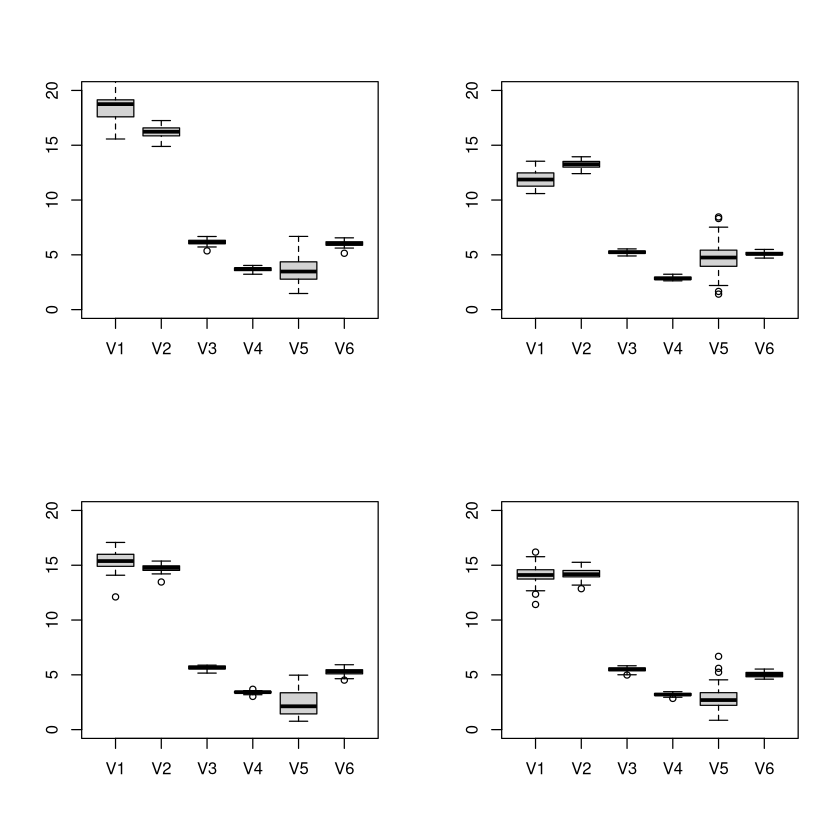

In [114]:
par(mfrow=c(2,2))
boxplot(datos[cl==1,],ylim=c(0,20))
boxplot(datos[cl==2,],ylim=c(0,20))
boxplot(datos[cl==3,],ylim=c(0,20))
boxplot(datos[cl==4,],ylim=c(0,20))
apply(datos[cl==1,],2,summary)
apply(datos[cl==2,],2,summary)
apply(datos[cl==3,],2,summary)
apply(datos[cl==4,],2,summary)

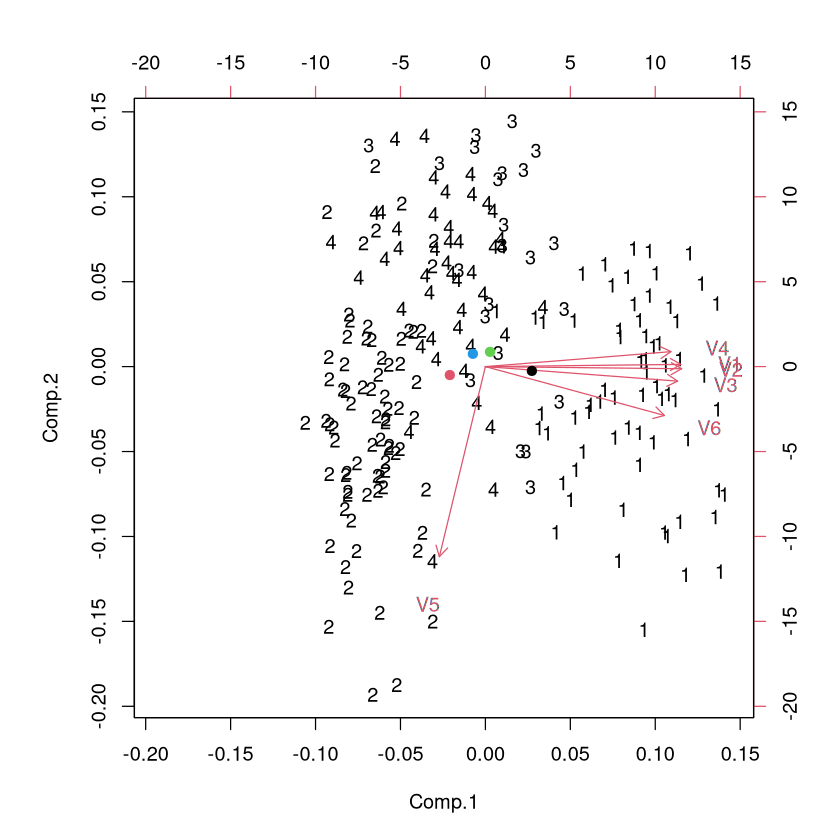

In [115]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos, cor=TRUE)
res2 <- predict(res,centers)

biplot(res,xlabs=cl)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:9,pch=19)


**Criterio de Información Bayesiano**

Una forma de discriminar entre posibles agrupamientos, es calcular el Criterio de Información Bayesiano, cuya expresión genérica es:
$$BIC = log L(Datos\mid \hat{\theta}) - \frac{d}{2}log(N)$$
donde $d$ es el número de parámetros libres y $N$ el número de observaciones. A medida que aumenta el número de parámetros la verosimilitud aumenta, pero esto es moderado por el término en que depende de $d$.

Mclust calcula automáticamente el BIC para distintas configuraciones de las matrices covarianza de cada Normal multivariada (que corresponden a distintos números de parámetros) así como distinto número de grupos. Por parsimonia, es recomendable escoger el primer número de grupos que representa un máximo local.

**Ejercicio 1:**

a) Explique como funciona el método Mclust, describa los principales parámetros de entrada y salida.

b) Utilice Mclust sin definir el número de grupos y considere el Criterio de información Bayesiano (BIC) para decidir el número de grupos óptimo. 

c) Interprete y comente los resultados obtenidos. Compare  sus resultados con aquellos obtenidos con k-means.

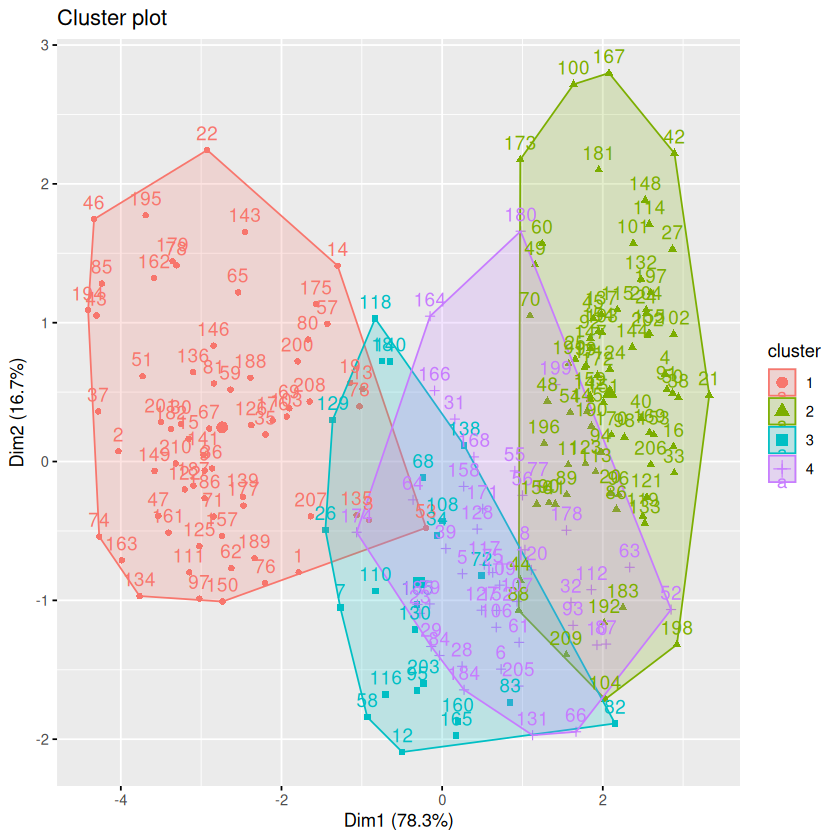

In [116]:
library(ggplot2)
library(cluster)
library(factoextra)
df <- data.frame(datos)
fviz_cluster(clus, df)

**Ejercicio 2:** 

a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.

Considere el archivo "semillas.txt" que contiene una séptima variable con la clasificación de las semillas en tres variedades: 
- 1: Kama
- 2: Rosa
- 3: Canadian

b) Calcule alguna de las medidas de calidad estudiadas para los agrupamientos obtenidos con KMeans (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos. Compare y discuta sus resultados.


In [117]:
datos1 <-read.table("..//data//semillas.txt",dec=".")
summary(datos1)

       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6              V7   
 Min.   :0.765   Min.   :4.519   Min.   :1  
 1st Qu.:2.562   1st Qu.:5.045   1st Qu.:1  
 Median :3.599   Median :5.223   Median :2  
 Mean   :3.700   Mean   :5.408   Mean   :2  
 3rd Qu.:4.769   3rd Qu.:5.877   3rd Qu.:3  
 Max.   :8.456   Max.   :6.550   Max.   :3  

In [118]:
purity <- function(clusters, clases) {
  sum(apply(table(clases, clusters), 2, max)) / length(clusters)
}



**Ejercicio 3:** 

a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM. 
b) Interprete sus resultados y compare con los obtenidos con k-means.

# **Desarrollo de los ejercicios**
## (Transparencia: Se uso IA generativa para entender mejor los conceptos claves de esta actividad y para algunas consultas de corrección de códigos para usar en el lenguaje R, los cuales fueron verificados en su funcionamiento, todo lo demás es redactado manualmente)
## **Ejercicio 1**
### a) Explique como funciona el método Mclust, describa los principales parámetros de entrada y salida.
R: De acuerdo con las definiciones, el método Mclust (el cual se puede importar como un paquete de R) realiza clustering basado en GMM's (Gaussian Mixture Models). La idea principal es suponer que los datos provienen de una mezcla de K distribuciones normales, cada una representando un grupo y donde cada observación tiene una cierta probabilidad de pertenecer a cada uno de esos grupos. Los parámetros del modelo (las medias, matrices de covarianza y proporciones de mezcla de cada componente) se estiman mediante el algoritmo EM (Expectation, Maximization), que itera entre los siguientes pasos: El primero consiste en calcular las probabilidades de que pertenezca cada punto a cada grupo (eso ocurre en el paso E) e ir actualizando los parámetros de cada distribución a partir de esas probabilidades (ese es el paso M), hasta que el procedimiento finalmente muestre convergencia. 

Una característica importante de Mclust es que prueba distintas configuraciones para la forma de las matrices de covarianza de las componentes normales, donde se analiza por ejemplo, si son esféricas o elipsoidales, esto se puede identificar usando códigos de tres letras como EEV, VII, VVV, entre otros. Luego se selecciona la combinación de modelo y número de grupos que maximiza el BIC, que premia un buen ajuste a los datos pero penaliza los modelos con más parámetros.

A continuacion se pueden observar algunos (hay más en la documentación) de los parámetros de entrada y salida que dispone Mclust:

In [119]:
names(clus)

[1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"

Despues de leer la documentación de R para este paquete podemos determinar que los principales parámetros de entrada son:
 
- data: La matriz o dataframe con las observaciones a agrupar.
- G: El número de grupos (componentes) a considerar. Podría ser un valor fijo (por ejemplo, G = 4) o ser determinado de otra forma como por ejemplo usando BIC.
- modelNames: Vector de strings que permite restringir las formas de las matrices de covarianza que el algoritmo evaluará. Si no se especifica, prueba todas las disponibles.

Mientras que los de salida son:
- classification: Vector con la asignación final de cada observación a un grupo.
- parameters: Lista con los parámetros estimados del modelo, incluyendo las medias (mean), las matrices de covarianza (variance) y las proporciones de mezcla (pro) de cada componente.
- z: Una matriz con las probabilidades de pertenencia de cada observación a cada uno de los grupos.
- uncertainty: Es una medida de incertidumbre para la asignación de cada observación.
- BIC y bic: Es el valor del BIC para todos los modelos evaluados y el del modelo seleccionado, respectivamente.


### b) Utilice Mclust sin definir el número de grupos y considere el Criterio de información Bayesiano (BIC) para decidir el número de grupos óptimo. 

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EEV (ellipsoidal, equal volume and shape) model with 2 components: 

 log-likelihood   n df      BIC       ICL
       80.12963 210 49 -101.749 -104.2238

Clustering table:
  1   2 
 71 139 

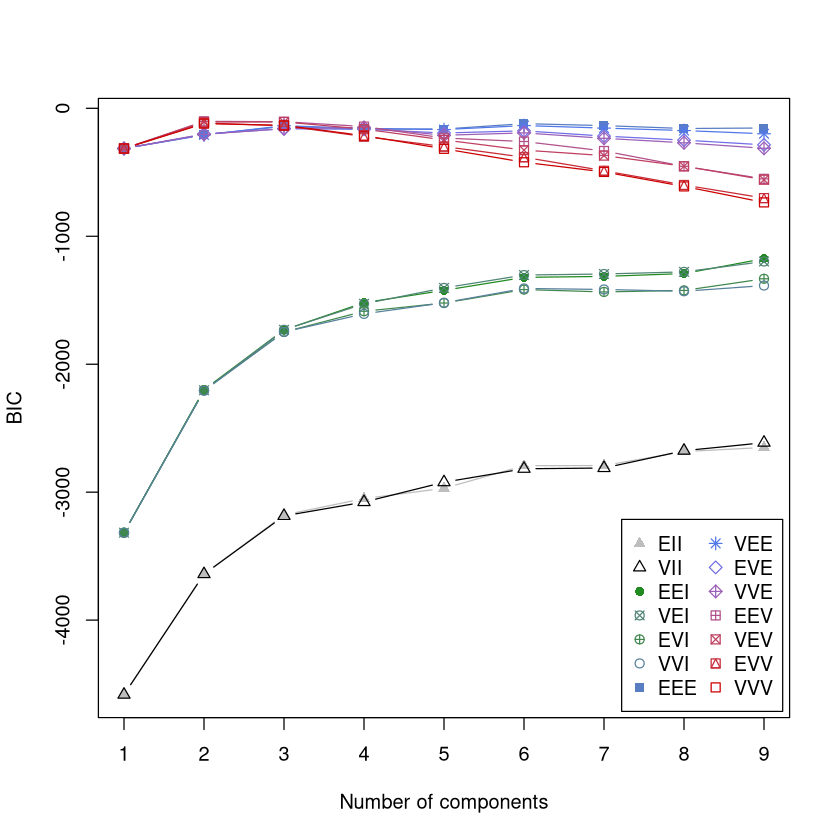

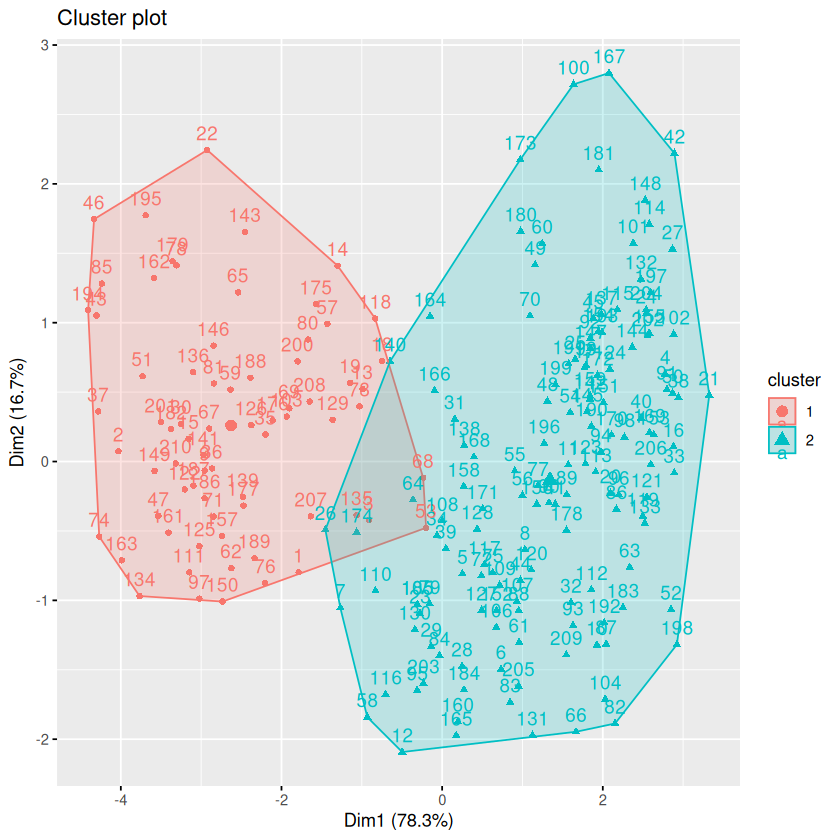

In [120]:
# Mclust sin fijar G: el BIC selecciona modelo y número de grupos
clus_bic <- Mclust(datos)
summary(clus_bic)
plot(clus_bic, what = "BIC")

# Visualización del agrupamiento seleccionado
library(factoextra)
fviz_cluster(clus_bic, data.frame(datos))

### c) Interprete y comente los resultados obtenidos. Compare  sus resultados con aquellos obtenidos con k-means.
Al aplicar Mclust sin fijar el número de grupos, nos dimos cuenta que el criterio BIC seleccionó un modelo EEV (elipsoidal, de volumen y forma iguales) con 2 componentes, con un BIC de -101.749 y una distribución de 71 observaciones en el primer grupo y 139 en el segundo. Este resultado es interesante, ya que sabemos que en realidad existen 3 variedades de semillas (Kama, Rosa y Canadian), pero el BIC favoreció la solución con K=2 (estos datos se obtienen de los resultados de las celdas de más arriba).

Si lo comparamos con los resultados obtenidos previamente por k-means tenemos una diferencia bastante clara ya que k-means con K=3 logró separar las tres variedades de semillas (Kama, Rosa y Canadian), mientras que GMM con BIC como mencionamos anteriormente se quedó en 2 grupos. Es posible explicar porque ocurre esta diferencia, ya que según lo que sabemos del BIC este tiende a penalizar fuertemente la cantidad de parámetros del modelo, y en un GMM con 3 o 4 componentes requiere muchos más grados de libertad, por lo que la mejora en verosimilitud no compensa el costo.

En conclusión, no creemos que los métodos puedan estar equivocados, sino que responden mejor a determinadas situaciones. GMM con BIC entrega una partición más conservadora, que podría ser útil cuando no se conoce el número real de grupos. K-means con K=3, en cambio, produce una segmentación más fiel a la estructura real del dominio, que ya sabemos de antemano que tiene tres variedades.

## **Ejercicio 2**
### a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.


1. Purity

Esta métrica evalúa qué tan "puro" es un clúster identificando cuál es la etiqueta o clase mayoritaria dentro de él. Se basa en calcular la proporción de los objetos que pertenecen a esa clase predominante en comparación con el total de objetos del clúster. Los resultados acá van de cero (malo) a uno (excelente). Su mayor problema es que no penaliza la creación de demasiados clústeres, por lo que sería posible obtener un puntaje perfecto de manera engañosa simplemente colocando cada objeto en su propio clúster individual.

2. Rand Index

Sirve para comparar dos agrupaciones diferentes (por ejemplo, los clústeres que generó el modelo frente a una agrupación de referencia). En lugar de mirar clústeres enteros, analiza todas las parejas posibles de datos. Se entiende fácilmente como el porcentaje o fracción de decisiones de agrupación que fueron correctas. Para lograrlo, suma los aciertos (las parejas que correctamente se pusieron en el mismo grupo, más las parejas que correctamente se separaron) y los evalúa frente al total de combinaciones posibles. Un detalle clave es que le da exactamente el mismo peso a equivocarse uniendo datos distintos (falsos positivos) que a equivocarse separando datos similares (falsos negativos). En la práctica se suele usar el Adjusted Rand Index (ARI) que corrige algunos problemas que presenta el rand index.

3. Mutual Information

Mide cuánta información comparten dos agrupaciones distintas. Lo hace calculando la probabilidad de que, si se elige un objeto al azar, este pertenezca a un clúster específico en la primera agrupación y a otro clúster específico en la segunda. Pero tiene un problema y es que el puntaje máximo se puede alcanzar de forma artificial si el modelo crea muchísimos clústeres pequeños. Para compensar este defecto, normalmente se aplica una versión normalizada. Esta normalización ajusta el cálculo para que el resultado final siempre sea un valor justo entre cero y uno.

### Considere el archivo "semillas.txt" que contiene una séptima variable con la clasificación de las semillas en tres variedades: 
### - 1: Kama
### - 2: Rosa
### - 3: Canadian

### b) Calcule alguna de las medidas de calidad estudiadas para los agrupamientos obtenidos con KMeans (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos. Compare y discuta sus resultados.


In [121]:
# Separamos predictoras y etiqueta verdadera
X       <- datos1[, 1:6]   # V1..V6
y_true  <- datos1[, 7]     # V7: 1=Kama, 2=Rosa, 3=Canadian

# KMeans con K=3
set.seed(123)
km    <- kmeans(X, centers = 3, nstart = 25)
cl_km <- km$cluster

# GMM con G=3
gmm3    <- Mclust(X, G = 3)
cl_gmm  <- gmm3$classification

# Tablas de contingencia
cat("Tabla k-means vs etiqueta real:\n")
print(table(KMeans = cl_km, Real = y_true))
cat("\nTabla GMM vs etiqueta real:\n")
print(table(GMM = cl_gmm, Real = y_true))

Tabla k-means vs etiqueta real:
      Real
KMeans  1  2  3
     1  1 60  0
     2 60 10  2
     3  9  0 68

Tabla GMM vs etiqueta real:
   Real
GMM  1  2  3
  1  0 68  0
  2 13  0 70
  3 57  2  0


In [122]:
#Purity
purity_km  <- purity(cl_km,  y_true)
purity_gmm <- purity(cl_gmm, y_true)

cat("Purity k-means:", round(purity_km,  4), "\n")
cat("Purity GMM   :", round(purity_gmm, 4), "\n")

Purity k-means: 0.8952 
Purity GMM   : 0.9286 


In [123]:
#Adjusted Rand Index
ari_km  <- adjustedRandIndex(cl_km,  y_true)
ari_gmm <- adjustedRandIndex(cl_gmm, y_true)

cat("Adjusted Rand Index k-means:", round(ari_km,  4), "\n")
cat("Adjusted Rand Index GMM   :", round(ari_gmm, 4), "\n")

Adjusted Rand Index k-means: 0.7166 
Adjusted Rand Index GMM   : 0.8051 


In [124]:
comparacion <- data.frame(
  Metodo = c("k-means", "GMM"),
  Purity = c(purity_km, purity_gmm),
  ARI    = c(ari_km,    ari_gmm)
)
comparacion

Metodo,Purity,ARI
<chr>,<dbl>,<dbl>
k-means,0.8952381,0.7166199
GMM,0.9285714,0.8051487


Al comparar, obtenemos los siguientes valores:
 
|Método|Purity|Adjusted Rand Index|
|---|---|---|
|k-means|0.8952|0.7166|
|GMM|0.9286|0.8051|
 
Lo primero que se nota es que ambos métodos funcionan bastante bien. Con purezas altas para los dos casos queda claro que las variables geométricas del grano (V1 a V6) por sí solas alcanzan para distinguir las tres variedades sin necesidad de supervisión.

Si comparamos los dos métodos entre ellos, el GMM queda por sobre k-means en las dos métricas (ligeramente en Purity y bastante mas ARI). Cabe mencionar que hay una diferencia en el comportamiento de estos metodos para este caso, y esto se puede notar en las primeras dos tablas, ya que esta nos muestra que k-means se equivoca tanto con Kama vs Rosa (10 casos) como con Kama vs Canadian (9 casos) y finalmente Rosa vs Canadian (2 casos) para un total de 21 errores. GMM, en cambio, logra separar Rosa casi perfectamente (con solo unas 2 confusiones), y sus errores se concentran mas en Kama vs Canadian (13 casos), y solo termina con 15 errores totales, bastante menos que k-means.

En conclusion, para este caso el GMM termina siendo un mejor clasificador no supervisado que k-means, esto es siempre y cuando tenga condiciones (como en este caso) que le resulten más favorables para así poder tomar la delantera.

## **Ejercicio 3:** 

### a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM. 

   distancia          tiempo          velocidad         modo_transporte_bus
 Min.   : 0.020   Min.   :0.05733   Min.   :  0.01573   Min.   :0.0000     
 1st Qu.: 8.675   1st Qu.:0.53700   1st Qu.: 12.12287   1st Qu.:0.0000     
 Median :15.615   Median :0.78542   Median : 18.95680   Median :0.0000     
 Mean   :16.820   Mean   :0.84357   Mean   : 26.45919   Mean   :0.3302     
 3rd Qu.:22.878   3rd Qu.:1.04221   3rd Qu.: 31.72714   3rd Qu.:1.0000     
 Max.   :77.310   Max.   :4.23100   Max.   :157.50000   Max.   :1.0000     
 modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
 Min.   :0.0000            Min.   :0.0000       Min.   :0.0000         
 1st Qu.:0.0000            1st Qu.:0.0000       1st Qu.:0.0000         
 Median :0.0000            Median :0.0000       Median :0.0000         
 Mean   :0.3767            Mean   :0.1047       Mean   :0.1512         
 3rd Qu.:1.0000            3rd Qu.:0.0000       3rd Qu.:0.0000         
 Max.   :1.0000            Max.   :1

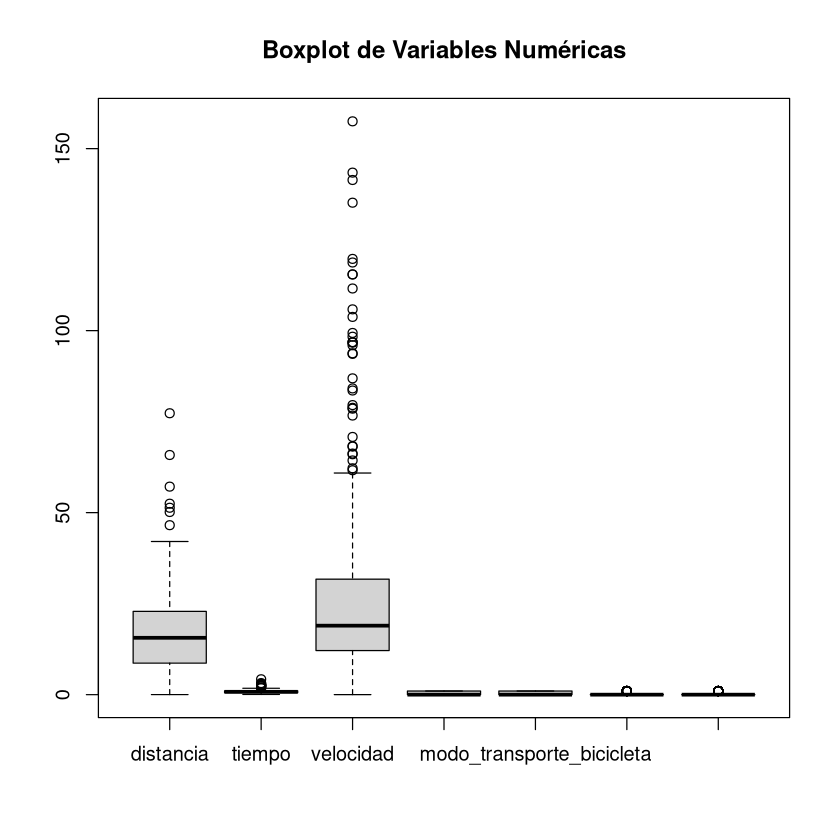

In [ ]:
# Se cargan los datos originales
datos_grupo <- read.csv("..//datasets_simulados//Grupo10.csv", dec=".", sep=",")

datos_grupo <- dummy_cols(datos_grupo, select_columns = "modo_transporte", remove_selected_columns = FALSE)

# Se filtran valores negativos y nulos (Ya que no tienen sentido logico)
datos_grupo <- datos_grupo[datos_grupo$distancia > 0 & datos_grupo$tiempo > 0 & datos_grupo$viajes > 0, ]
datos_grupo <- na.omit(datos_grupo)

# Agregamos velocidad (en kilometros) promedio antes de filtrar. Tambien quitamos velocidades que no tienen sentido 
# (Velocidades sobre 160 kilometros por hora, teniendo en cuenta que la velocidad maxima en chile es 120km/h en autopista y que algunos trenes efe podrian llegar a 160km/h en algunos tramos).
datos_grupo$tiempo <- datos_grupo$tiempo / 60
datos_grupo$velocidad <- datos_grupo$distancia / datos_grupo$tiempo
datos_grupo <- datos_grupo[datos_grupo$velocidad <= 160, ]

# Solo usamos los datos numericos.
datos_num <- datos_grupo[ , c("distancia", "tiempo", "velocidad", "modo_transporte_bus", "modo_transporte_bicicleta", "modo_transporte_auto", "modo_transporte_caminar")]

summary(datos_num)
boxplot(datos_num, main="Boxplot de Variables Numéricas")

In [126]:
datos_scale = scale(datos_num)
clus <- Mclust(datos_scale)
summary(clus)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEV (ellipsoidal, equal shape) model with 2 components: 

 log-likelihood   n df       BIC       ICL
      -1942.054 430 65 -4278.254 -4278.254

Clustering table:
  1   2 
274 156 

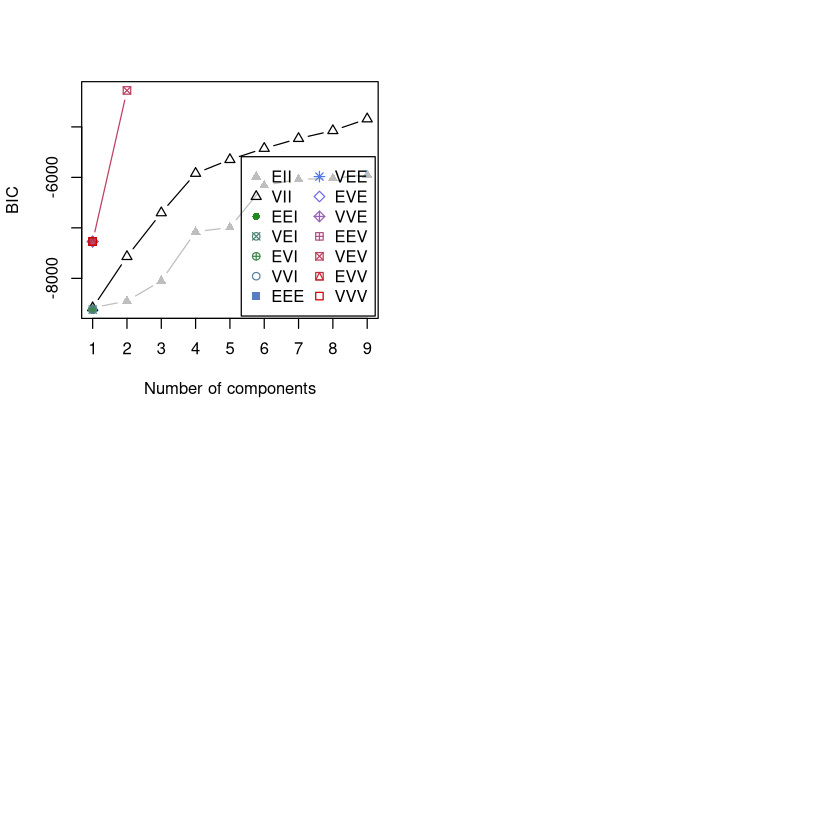

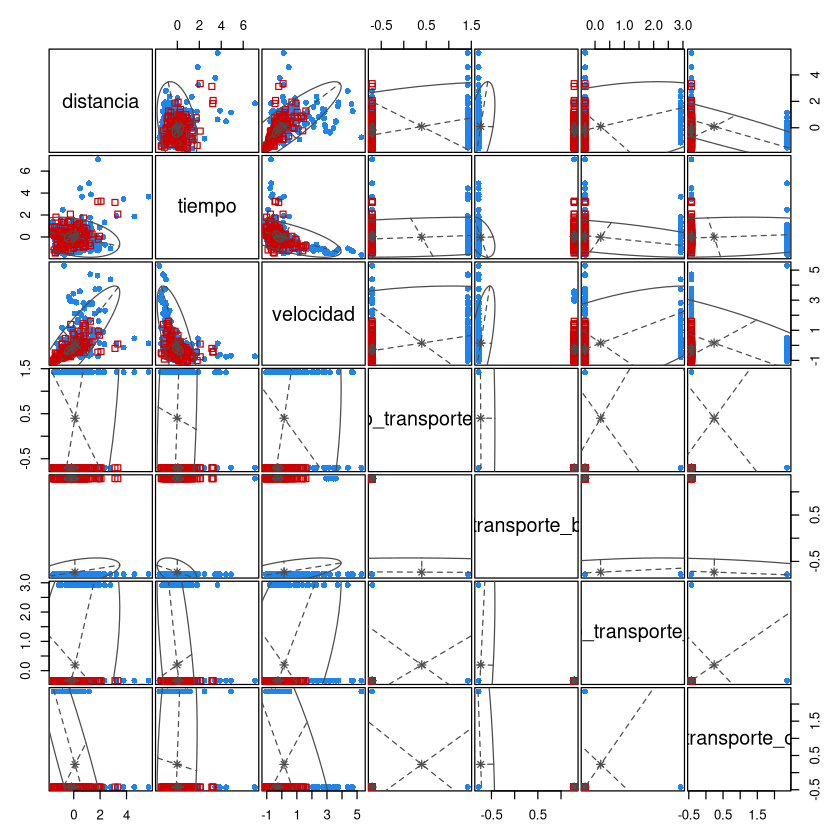

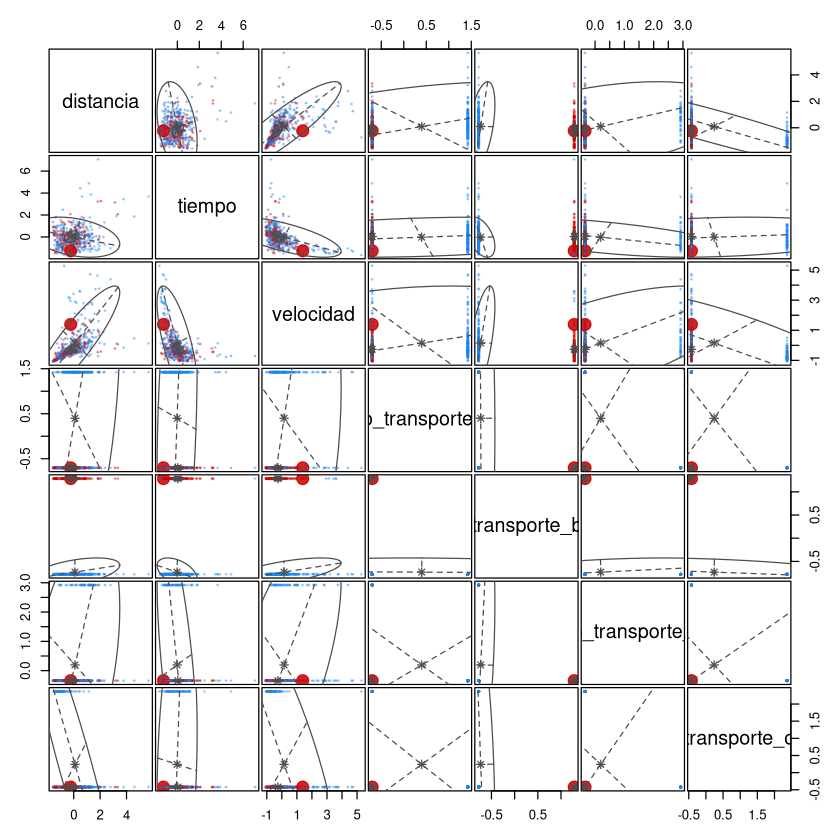

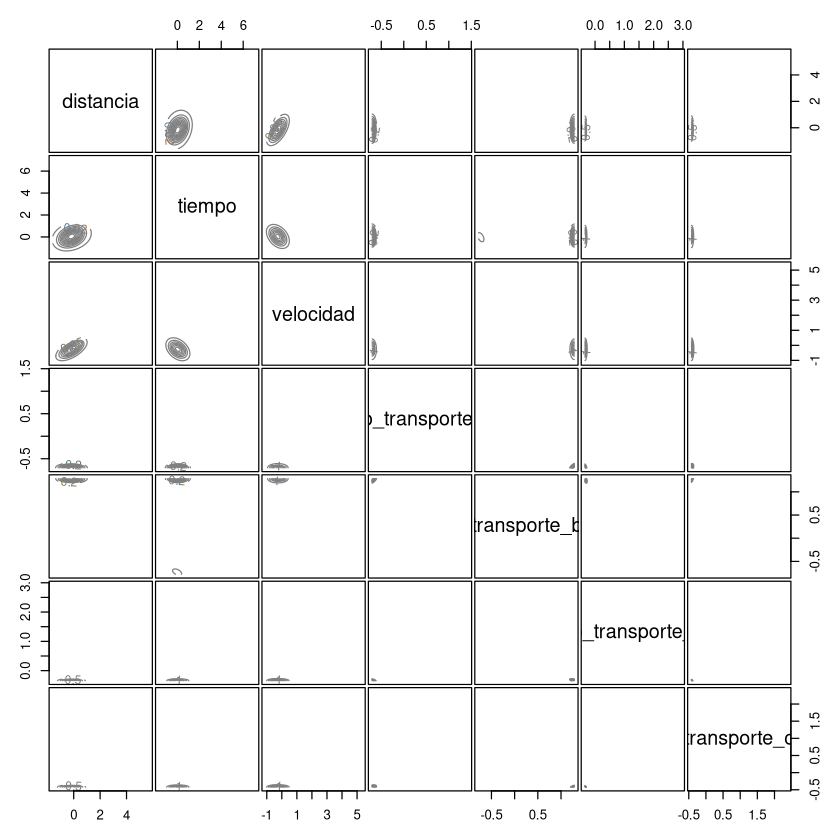

In [127]:
par(mfrow = c(2, 2))
plot(clus, what = "BIC")            # curva BIC → G óptimo
plot(clus, what = "classification") # mapa de clusters
plot(clus, what = "uncertainty")    # incertidumbre de asignación
plot(clus, what = "density")        # densidad estimada

In [128]:
cl <- clus$classification
for (g in 1:clus$G) {
  cat("\n--- Cluster", g, "(n =", sum(cl == g), ") ---\n")
  print(apply(datos_scale[cl == g, ], 2, summary))
}


--- Cluster 1 (n = 274 ) ---
          distancia      tiempo  velocidad modo_transporte_bus
Min.    -1.57024717 -1.64149059 -1.0659147          -0.7013622
1st Qu. -0.74951449 -0.72965747 -0.5658971          -0.7013622
Median  -0.01825666 -0.16282818 -0.2152963           1.4224811
Mean     0.09572829 -0.02345309  0.1498973           0.3993157
3rd Qu.  0.74321649  0.42244307  0.3857227           1.4224811
Max.     5.66737834  7.07216137  5.2870165           1.4224811
        modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
Min.                   -0.7765770           -0.3414840              -0.4215069
1st Qu.                -0.7765770           -0.3414840              -0.4215069
Median                 -0.7765770           -0.3414840              -0.4215069
Mean                   -0.7314394            0.1944215               0.2399820
3rd Qu.                -0.7765770           -0.3414840              -0.4215069
Max.                    1.2847076            2.9215850 

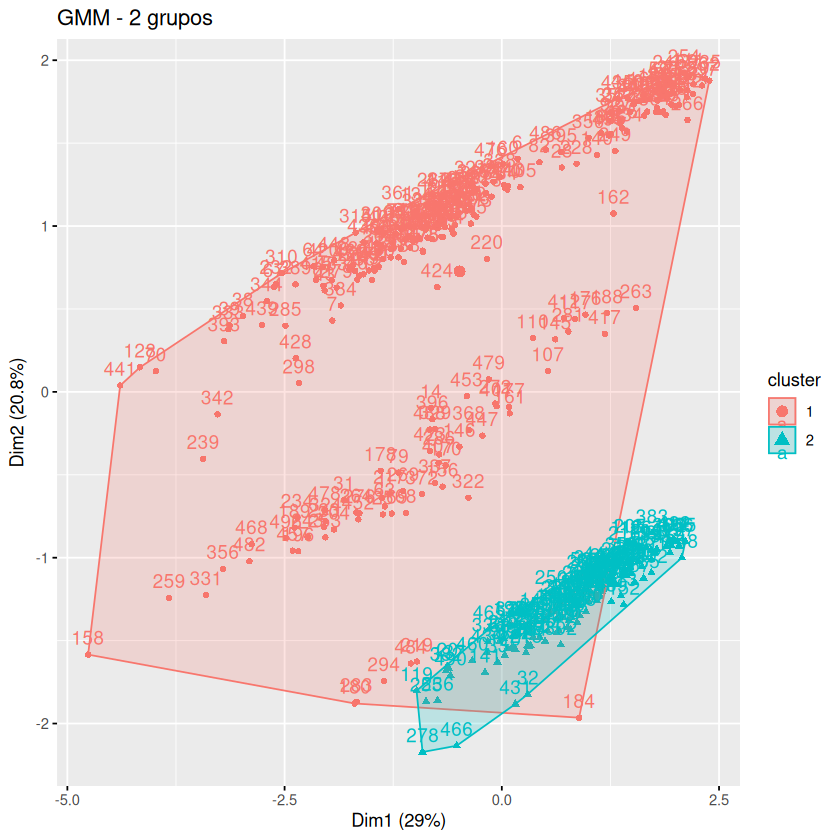

In [129]:
fviz_cluster(clus, datos_scale, main = paste("GMM -", clus$G, "grupos"))

### b) Interprete sus resultados y compare con los obtenidos con k-means.

Utilizando GMM se obtuvo un total de 2 grupos, a diferencia de K-Means donde se obtuvo un k óptimo de 4. Esta diferencia refleja en parte una decisión metodológica incorrecta en el preprocesamiento de los datos.
Tanto GMM como K-Means están diseñados para variables numéricas continuas. Al incorporar la variable categórica modo_transporte como columna binaria, se introdujo una estructura artificial en los datos que distorsiona los resultados. Si bien en K-Means los gráficos parecían satisfactorios, GMM dejó en evidencia esta falencia a través de las líneas diagonales observadas en la visualización, las cuales son un artefacto directo de las variables dummy y no representan grupos reales.
Desde un principio el objetivo fue buscar patrones que fueran más allá de simplemente agrupar por tipo de transporte, razón por la cual se mantuvo y transformó dicha columna. Sin embargo, la información del modo de transporte no permite observar directamente patrones de movilidad: indica el medio utilizado, pero no cómo se mueve la gente. Para capturar patrones de movilidad habría sido más pertinente incorporar la variable viajes, que representa la cantidad de viajes realizados, ya que junto a distancia, tiempo y velocidad podría haber revelado comportamientos de desplazamiento más significativos.

En conclusión, los resultados obtenidos con ambos métodos difieren considerablemente. K-Means generó una ilusión de buen agrupamiento, mientras que GMM expuso por qué no es adecuado utilizar variables categóricas codificadas como binarias en estos modelos.